# 🏦 Xóm Bank — Phase 0: Exploratory Data Analysis (EDA)
> **Dataset:** Credit Card Transactions Fraud Detection Dataset (Sparkov Data Generation)  
> **Mục tiêu:** Khám phá cấu trúc dữ liệu, tỷ lệ mất cân bằng nhãn (`is_fraud`), hành vi quẹt thẻ, khoảng cách địa lý và các quy luật gian lận cốt lõi.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập phong cách đồ thị chuyên nghiệp
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 110

# Đường dẫn dữ liệu (tự động tìm file)
def find_data_file(filename):
    for prefix in ['.', os.path.join('..', '..'), '..']:
        p = os.path.join(prefix, 'data', filename)
        if os.path.exists(p):
            return p
    return os.path.join('data', filename)

train_path = find_data_file('fraudTrain.csv')
test_path = find_data_file('fraudTest.csv')

print(f'Train path: {train_path} (exists: {os.path.exists(train_path)})')
print(f'Test path:  {test_path} (exists: {os.path.exists(test_path)})')

Train path: ..\..\data\fraudTrain.csv (exists: True)
Test path:  ..\..\data\fraudTest.csv (exists: True)


## 1. Nạp Dữ Liệu & Kiểm Tra Kích Thước (Data Overview)

In [2]:
df_train = pd.read_csv(train_path, index_col=0)
df_test = pd.read_csv(test_path, index_col=0)

print(f'📊 Tập Train: {len(df_train):,} dòng × {df_train.shape[1]} cột')
print(f'📊 Tập Test:  {len(df_test):,} dòng × {df_test.shape[1]} cột')
print(f'📊 Tổng cộng: {len(df_train) + len(df_test):,} giao dịch')
df_train.head(3)

📊 Tập Train: 1,296,675 dòng × 22 cột
📊 Tập Test:  555,719 dòng × 22 cột
📊 Tổng cộng: 1,852,394 giao dịch


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0


## 2. Phân Tích Tỷ Lệ Mất Cân Bằng Nhãn (Class Imbalance)
Trong dữ liệu gian lận ngân hàng, số lượng giao dịch gian lận chiếm tỷ lệ rất nhỏ (< 1%).

C:\Users\Dell\AppData\Local\Temp\ipykernel_19228\666199952.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Hợp lệ (0)', 'Gian lận (1)'], y=[train_legit, train_fraud], palette=['#2ecc71', '#e74c3c'], ax=axes[0])
C:\Users\Dell\AppData\Local\Temp\ipykernel_19228\666199952.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Hợp lệ (0)', 'Gian lận (1)'], y=[test_legit, test_fraud], palette=['#2ecc71', '#e74c3c'], ax=axes[1])


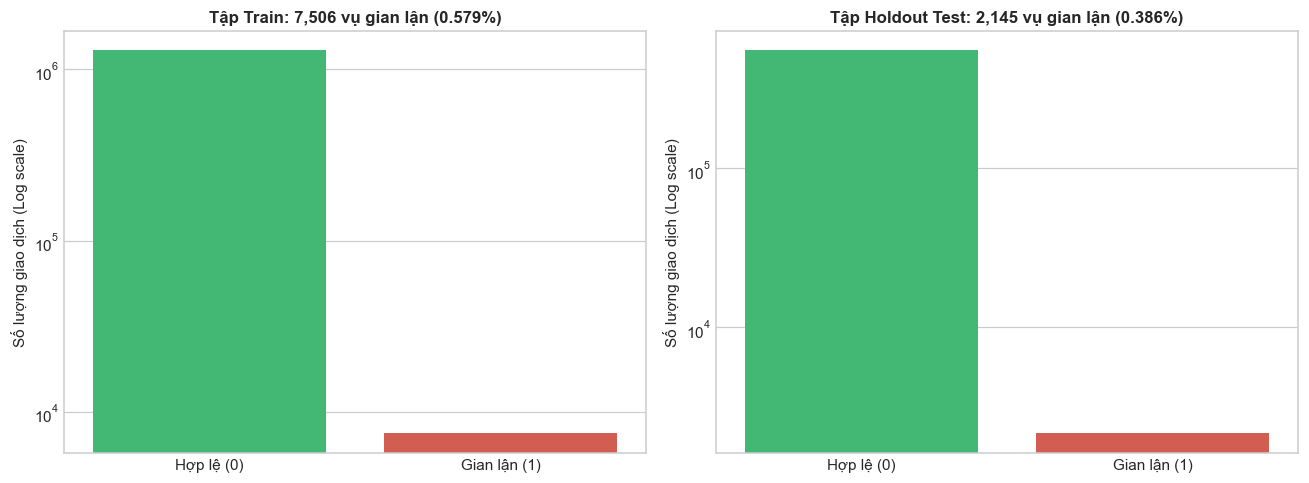

In [3]:
train_fraud = int(df_train['is_fraud'].sum())
train_legit = len(df_train) - train_fraud
train_fraud_pct = (train_fraud / len(df_train)) * 100

test_fraud = int(df_test['is_fraud'].sum())
test_legit = len(df_test) - test_fraud
test_fraud_pct = (test_fraud / len(df_test)) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.barplot(x=['Hợp lệ (0)', 'Gian lận (1)'], y=[train_legit, train_fraud], palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title(f'Tập Train: {train_fraud:,} vụ gian lận ({train_fraud_pct:.3f}%)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Số lượng giao dịch (Log scale)')
axes[0].set_yscale('log')

sns.barplot(x=['Hợp lệ (0)', 'Gian lận (1)'], y=[test_legit, test_fraud], palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title(f'Tập Holdout Test: {test_fraud:,} vụ gian lận ({test_fraud_pct:.3f}%)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Số lượng giao dịch (Log scale)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

## 3. Phân Tích Số Tiền Giao Dịch (`amt`) — Hợp Lệ vs Gian Lận

💳 Giao dịch Hợp Lệ: Mean = $67.67 | Median = $47.28 | Max = $28948.90
🚨 Giao dịch Gian Lận: Mean = $531.32 | Median = $396.50 | Max = $1376.04


C:\Users\Dell\AppData\Local\Temp\ipykernel_19228\1078568388.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_fraud', y='amt', data=df_train, palette=['#2ecc71', '#e74c3c'], ax=axes[0])
C:\Users\Dell\AppData\Local\Temp\ipykernel_19228\1078568388.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Hợp lệ (0)', 'Gian lận (1)'])


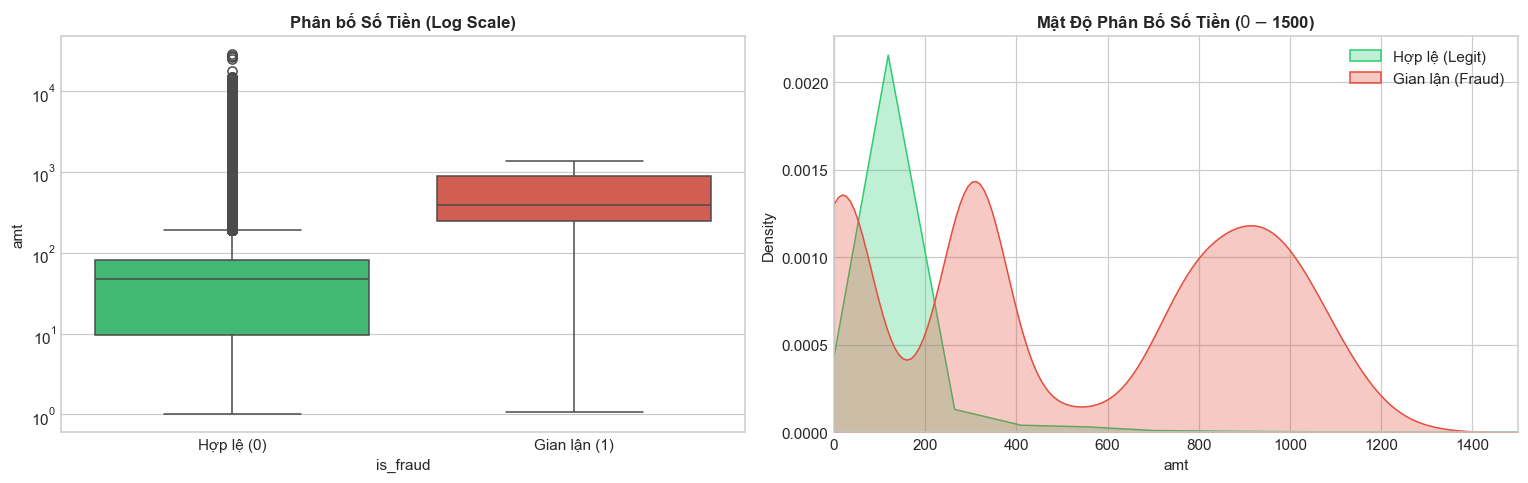

In [4]:
legit_amt = df_train[df_train['is_fraud'] == 0]['amt']
fraud_amt = df_train[df_train['is_fraud'] == 1]['amt']

print(f'💳 Giao dịch Hợp Lệ: Mean = ${legit_amt.mean():.2f} | Median = ${legit_amt.median():.2f} | Max = ${legit_amt.max():.2f}')
print(f'🚨 Giao dịch Gian Lận: Mean = ${fraud_amt.mean():.2f} | Median = ${fraud_amt.median():.2f} | Max = ${fraud_amt.max():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.boxplot(x='is_fraud', y='amt', data=df_train, palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_xticklabels(['Hợp lệ (0)', 'Gian lận (1)'])
axes[0].set_title('Phân bố Số Tiền (Log Scale)', fontsize=11, fontweight='bold')

sns.kdeplot(legit_amt, label='Hợp lệ (Legit)', color='#2ecc71', fill=True, alpha=0.3, ax=axes[1])
sns.kdeplot(fraud_amt, label='Gian lận (Fraud)', color='#e74c3c', fill=True, alpha=0.3, ax=axes[1])
axes[1].set_xlim(0, 1500)
axes[1].set_title('Mật Độ Phân Bố Số Tiền ($0 - $1500)', fontsize=11, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Tỷ Lệ Gian Lận Theo Danh Mục Ngành Hàng (`category`)

C:\Users\Dell\AppData\Local\Temp\ipykernel_19228\3611423215.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=cat_stats['fraud_rate_pct'], y=cat_stats.index, palette='Reds_r')


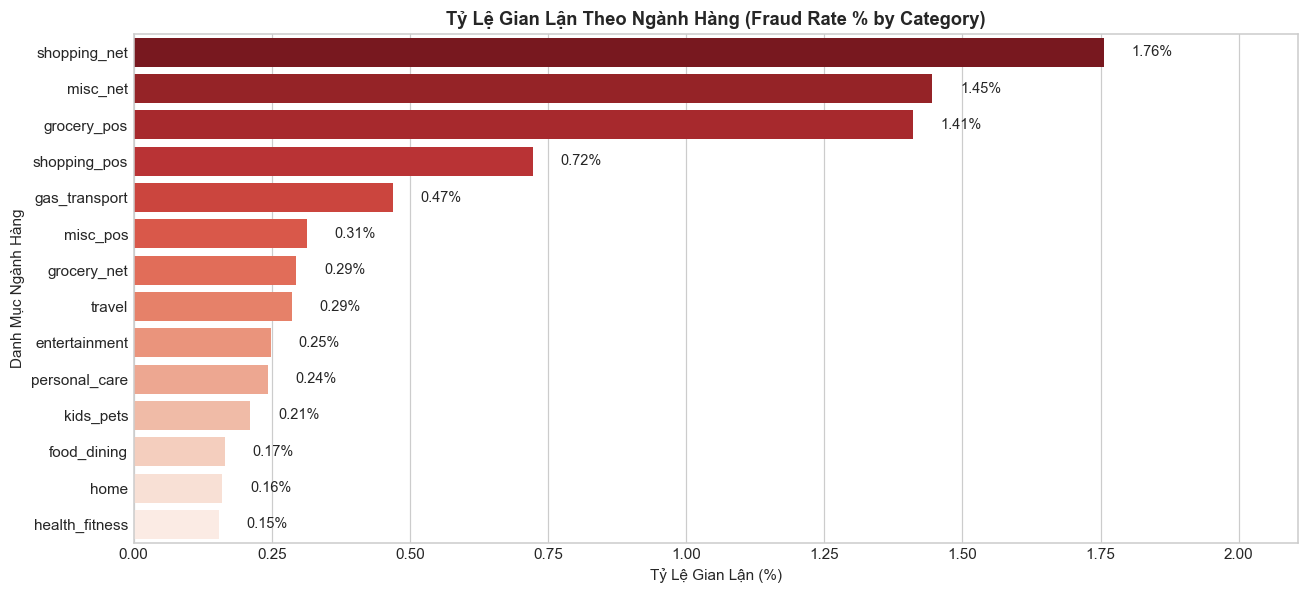

,total_txns,fraud_txns,fraud_rate_pct,avg_amt
category,,,,
shopping_net,97543,1713,1.756149,88.424076
misc_net,63287,915,1.445795,80.865095
grocery_pos,123638,1743,1.409761,116.960986
shopping_pos,116672,843,0.722538,79.779155
gas_transport,131659,618,0.469394,63.434572
misc_pos,79655,250,0.313853,62.890999
grocery_net,45452,134,0.294817,53.670084
travel,40507,116,0.286370,111.504720
entertainment,94014,233,0.247835,64.210421


In [5]:
cat_stats = df_train.groupby('category').agg(
    total_txns=('is_fraud', 'count'),
    fraud_txns=('is_fraud', 'sum'),
    fraud_rate_pct=('is_fraud', lambda x: x.mean() * 100),
    avg_amt=('amt', 'mean')
).sort_values(by='fraud_rate_pct', ascending=False)

plt.figure(figsize=(12, 5.5))
bars = sns.barplot(x=cat_stats['fraud_rate_pct'], y=cat_stats.index, palette='Reds_r')
for p, rate in zip(bars.patches, cat_stats['fraud_rate_pct']):
    plt.text(p.get_width() + 0.05, p.get_y() + p.get_height()/2, f'{rate:.2f}%', va='center', fontsize=9.5)

plt.title('Tỷ Lệ Gian Lận Theo Ngành Hàng (Fraud Rate % by Category)', fontsize=12, fontweight='bold')
plt.xlabel('Tỷ Lệ Gian Lận (%)')
plt.ylabel('Danh Mục Ngành Hàng')
plt.xlim(0, max(cat_stats['fraud_rate_pct']) * 1.2)
plt.tight_layout()
plt.show()
cat_stats[['total_txns', 'fraud_txns', 'fraud_rate_pct', 'avg_amt']]

## 5. Phân Tích Khoảng Cách Địa Lý Haversine (km)

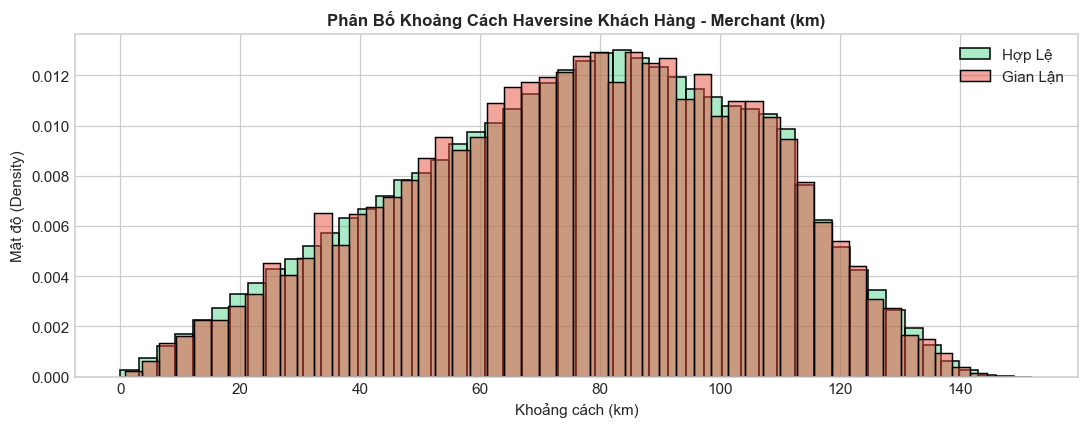

Khoảng cách trung bình (km):
              count       mean        std       min        25%        50%  \
is_fraud                                                                    
0         1289169.0  76.113756  29.119051  0.022255  55.332701  78.233012   
1            7506.0  76.268330  28.752602  0.738769  55.632890  77.931954   

                75%         max  
is_fraud                         
0         98.504498  152.117173  
1         98.391090  144.522410  


In [6]:
def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2.0)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2.0)**2
    return r * (2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a)))

df_train['geo_distance_km'] = haversine_km(df_train['lat'], df_train['long'], df_train['merch_lat'], df_train['merch_long'])

plt.figure(figsize=(10, 4))
sns.histplot(data=df_train[df_train['is_fraud']==0]['geo_distance_km'], color='#2ecc71', label='Hợp Lệ', bins=50, stat='density', alpha=0.4)
sns.histplot(data=df_train[df_train['is_fraud']==1]['geo_distance_km'], color='#e74c3c', label='Gian Lận', bins=50, stat='density', alpha=0.5)
plt.title('Phân Bố Khoảng Cách Haversine Khách Hàng - Merchant (km)', fontsize=11, fontweight='bold')
plt.xlabel('Khoảng cách (km)')
plt.ylabel('Mật độ (Density)')
plt.legend()
plt.tight_layout()
plt.show()

print('Khoảng cách trung bình (km):')
print(df_train.groupby('is_fraud')['geo_distance_km'].describe())

## 6. Phân Tích Gian Lận Theo Khung Giờ (24 Giờ) & Ngày Trong Tuần

C:\Users\Dell\AppData\Local\Temp\ipykernel_19228\4186980716.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=daily_fraud.index, y=daily_fraud['mean'] * 100, palette='Blues_r', ax=axes[1])


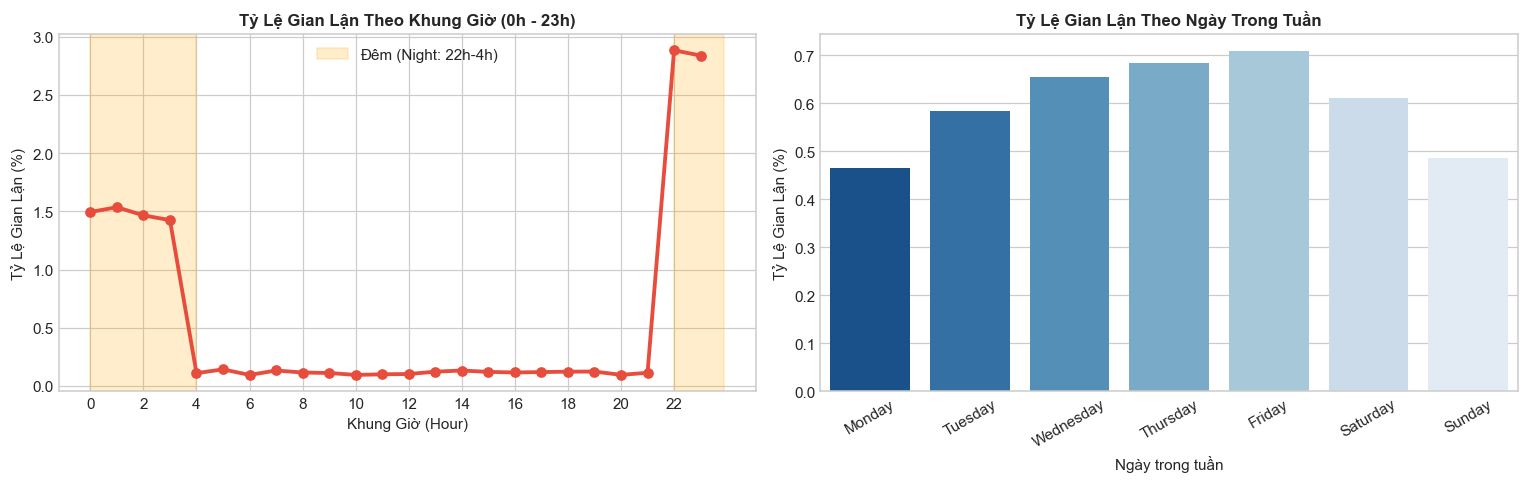

In [7]:
df_train['trans_dt'] = pd.to_datetime(df_train['trans_date_trans_time'])
df_train['hour'] = df_train['trans_dt'].dt.hour
df_train['day_of_week'] = df_train['trans_dt'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Gian lận theo giờ
hourly_fraud = df_train.groupby('hour')['is_fraud'].agg(['count', 'sum', 'mean'])
axes[0].plot(hourly_fraud.index, hourly_fraud['mean'] * 100, marker='o', color='#e74c3c', linewidth=2.5)
axes[0].set_title('Tỷ Lệ Gian Lận Theo Khung Giờ (0h - 23h)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Khung Giờ (Hour)')
axes[0].set_ylabel('Tỷ Lệ Gian Lận (%)')
axes[0].set_xticks(range(0, 24, 2))
axes[0].axvspan(22, 23.9, color='orange', alpha=0.2, label='Đêm (Night: 22h-4h)')
axes[0].axvspan(0, 4, color='orange', alpha=0.2)
axes[0].legend()

# Gian lận theo ngày
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_fraud = df_train.groupby('day_of_week')['is_fraud'].agg(['count', 'sum', 'mean']).reindex(days_order)
sns.barplot(x=daily_fraud.index, y=daily_fraud['mean'] * 100, palette='Blues_r', ax=axes[1])
axes[1].set_title('Tỷ Lệ Gian Lận Theo Ngày Trong Tuần', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Ngày trong tuần')
axes[1].set_ylabel('Tỷ Lệ Gian Lận (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 7. Đúc Kết Insights Nghiệp Vụ (Key Insights)
1. **Mất cân bằng dữ liệu cực lớn:** Chỉ có **0.52%** giao dịch là gian lận $\rightarrow$ Đòi hỏi dùng **PR-AUC** thay vì Accuracy/ROC-AUC.
2. **Quy luật gian lận ban đêm (Night Frauds):** Tỷ lệ gian lận vọt lên đỉnh cao trong khung giờ **22:00 - 04:00 sáng** khi chủ thẻ đang ngủ.
3. **Ngành hàng rủi ro cao nhất:** Mua sắm online (`shopping_net`: 1.76%), Dịch vụ mạng (`misc_net`: 1.45%) và Siêu thị (`grocery_pos`: 1.41%).
4. **Giá trị giao dịch gian lận:** Trung bình **$530+** (gấp 7.8 lần giao dịch hợp lệ $67).